In [3]:
import scipy.linalg as la
import numpy as np
import copy
import time
import random
import matplotlib.pyplot as plt
import pandas as pd
import csv, ast
from qutip import *
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import yfinance as yf
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import scienceplots
from fitting_model import *
from ESN_model import *
from extracter import *
from tasks import *
rng = np.random.default_rng(43)
np.random.seed(43)
random.seed(43)
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "Arial",          
    "font.size": 8,

    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    "lines.linewidth": 1.5,
    "lines.markersize": 4,

    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,

    "pdf.fonttype": 42,   
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})

LoadError: ArgumentError: Package scipy not found in current path.
- Run `import Pkg; Pkg.add("scipy")` to install the scipy package.

In [2]:
task = mackey_glass(Npoints=1000)

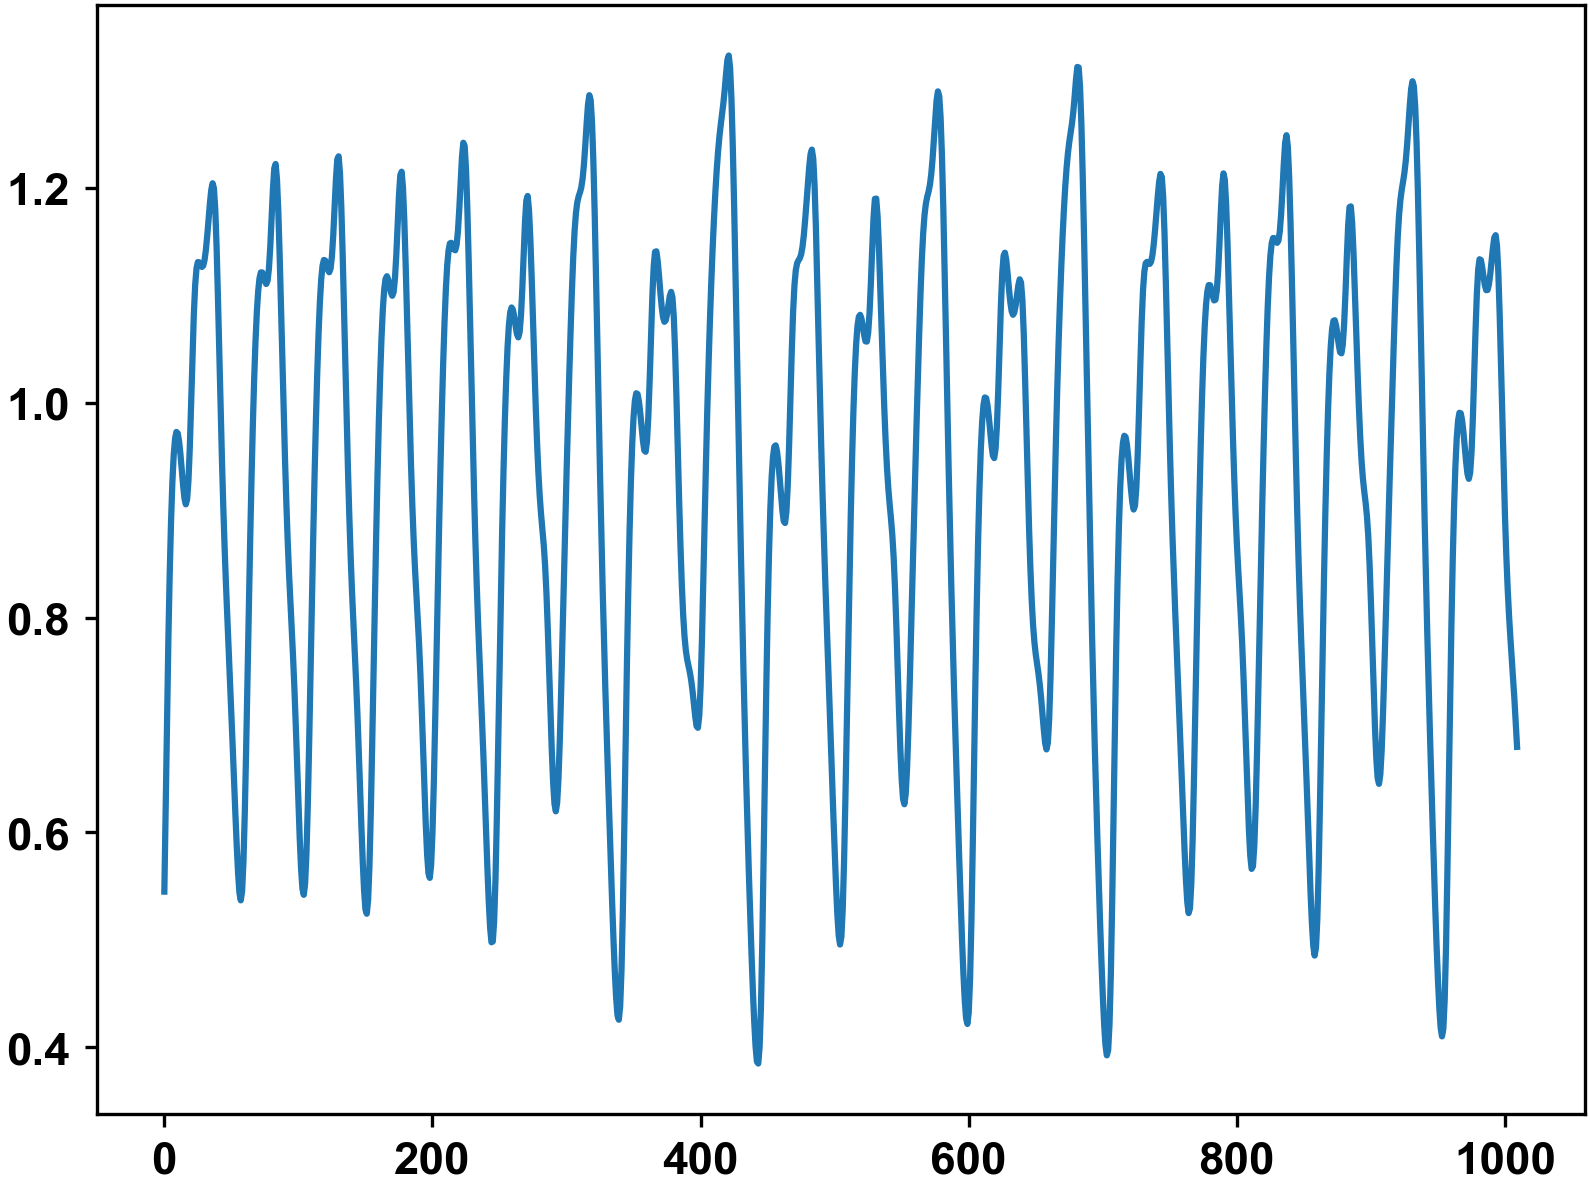

In [3]:
plt.plot(task[:])

In [4]:
N = 4
A, B = make_esn_weights(
    N,
    input_scale=1.0,
    spectral_radius=0.95,
    connectivity=0.1,)

X = esn_dynamics(task, A, B)
# Generate ESN reservoir states for full time series
X.shape

(1010, 4)

In [5]:
Nfading = 100
Ntraining = 700
Ntotal = 1000
Ntesting = Ntotal - Nfading - Ntraining
tau = 10
K = Ntotal-tau

NRMSE: 0.16745676460206788


Text(0.5, 1.0, 'Mackey Glass Prediction by ESN')

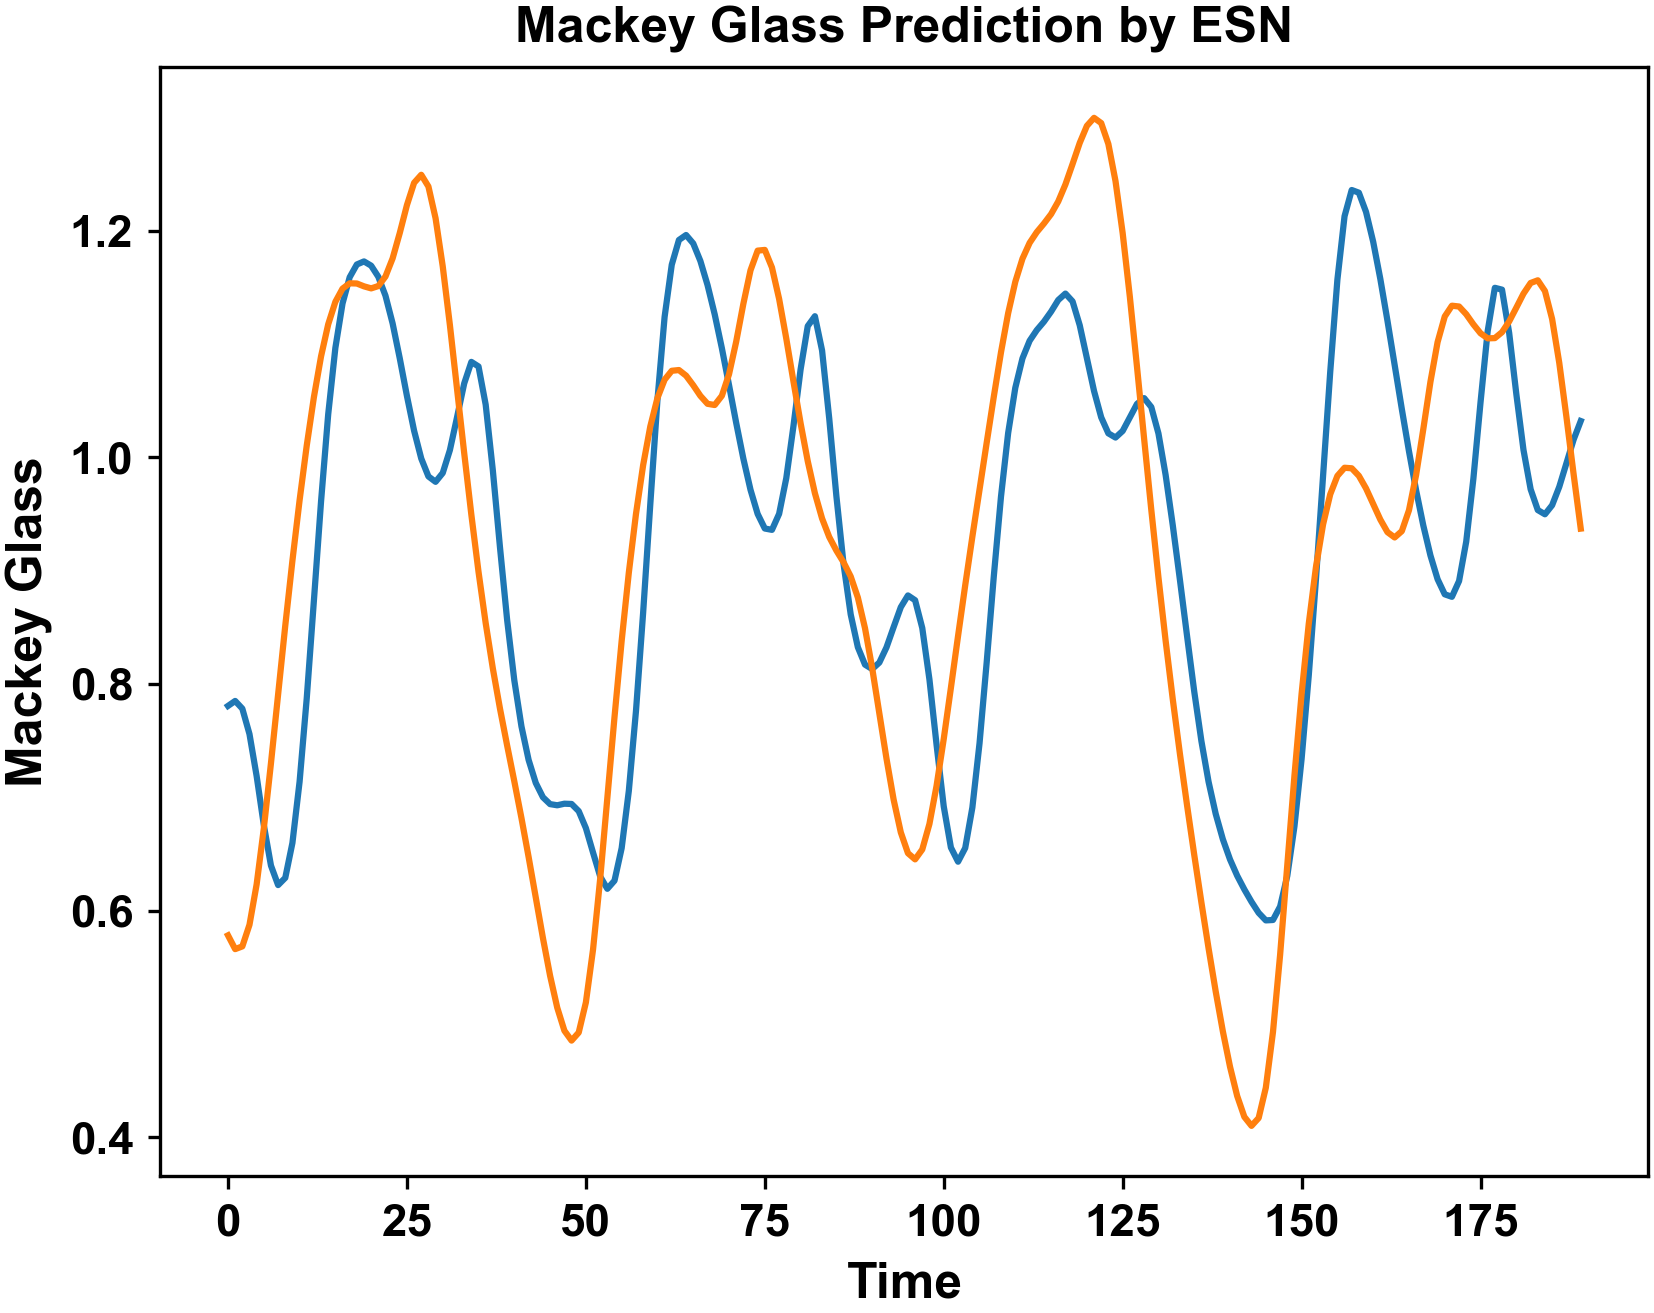

In [6]:
X_features = X[0:K]
X_train = X_features[Nfading : Nfading + Ntraining, :]
X_test = X_features[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]

y_target = task[tau : K + tau]
y_train = y_target[Nfading : Nfading + Ntraining]
y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]
W = fitting_function(X_train, y_train)
y_prediction = predict(X_test, W)
error = nrmse(y_prediction, y_test)
print("NRMSE:", error)
plt.plot(y_prediction)
plt.plot(y_test)
plt.xlabel("Time")
plt.ylabel("Mackey Glass")
plt.title("Mackey Glass Prediction by ESN")

Quantum Performance

In [8]:
df = pd.read_csv("MG_omega0.16_rep10.csv")
X = extract_delayed_single_column(df, 'PQ-10', N=4, repeat_steps=10)
X.shape

(1000, 4)

Pick any reservoir here, we show the performance on the mackey glass task.

NRMSE: 0.1645027871087001


Text(0.5, 1.0, 'BTC Prediction by ESN')

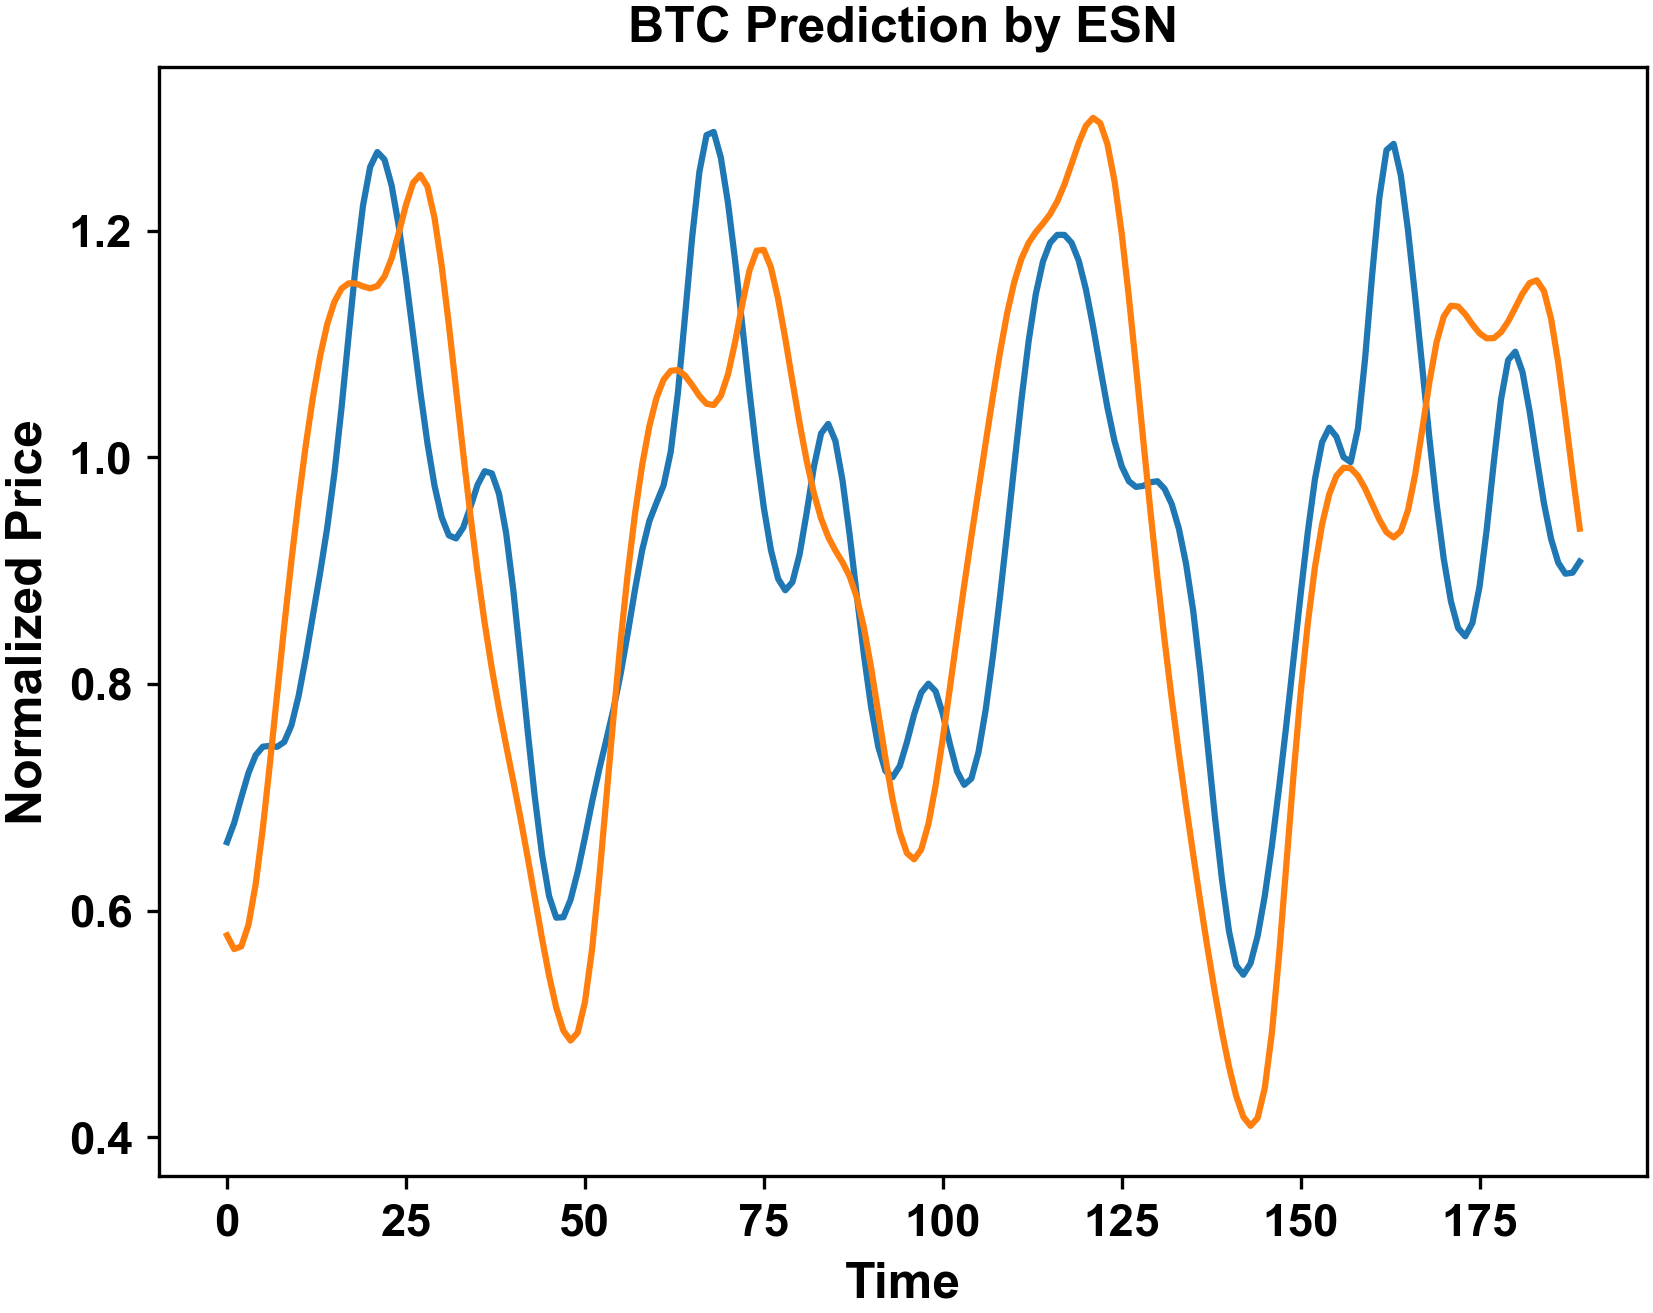

In [10]:
X_features = X[0:K]
X_train = X_features[Nfading : Nfading + Ntraining, :]
X_test = X_features[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]

y_target = task[tau : K + tau]
y_train = y_target[Nfading : Nfading + Ntraining]
y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]
W = fitting_function(X_train, y_train)
y_prediction = predict(X_test, W)
error = nrmse(y_prediction, y_test)
print("NRMSE:", error)
plt.plot(y_prediction)
plt.plot(y_test)
plt.xlabel("Time")
plt.ylabel("Normalized Price")
plt.title("BTC Prediction by ESN")

Pick any reservoir here, we show the performance is comparable to ESN

In [12]:
rep = 10
omega = .1
name = f'MG_omega{omega}_rep{rep}.csv'

In [31]:
nodes = [2,4,6,8,10,12,14,16,18,20,40,50,60,70]
ESN_errors = []
ESN_errors_all = []
Quantum_errors = []
Nfading = 100
Ntraining = 500
Ntotal = 1000
Ntesting = Ntotal - Nfading - Ntraining
tau = 10
K = Ntotal-tau
for r in range(50):
    ESN_errors = []
    for node in nodes: 
        A, B = make_esn_weights(node,input_scale=1.0,spectral_radius=0.95,connectivity=0.1)
        X_ESN= esn_dynamics(task, A, B)
        X_features_ESN = X_ESN[0:K]
        X_train_ESN = X_features_ESN[Nfading : Nfading + Ntraining, :]
        X_test_ESN = X_features_ESN[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]
        y_target = task[tau : K + tau]
        y_train = y_target[Nfading : Nfading + Ntraining]
        y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]
        W_ESN = fitting_function(X_train_ESN, y_train)
        y_prediction_ESN = predict(X_test_ESN, W_ESN)
        error = nrmse(y_prediction_ESN, y_test)
        ESN_errors.append(error)
    ESN_errors_all.append(ESN_errors)

ESN_errors_all = np.array(ESN_errors_all)
mean_errors = ESN_errors_all.mean(axis=0)
std_errors = ESN_errors_all.std(axis=0)


In [32]:
for node in nodes: 
    df = pd.read_csv(name)
    X_quantum = extract_delayed_single_column(df, 'PQ-10', N=node, repeat_steps=10)
    X_quantum = add_polynomial_features(X_quantum,nodes=node)
    """cols = np.random.choice(X_quantum.shape[1], size=node, replace=False)
    X_quantum = X_quantum[:, cols]"""
    X_features_quantum = X_quantum[0:K]
    print(X_features_quantum.shape)
    X_train_quantum = X_features_quantum[Nfading : Nfading + Ntraining, :]
    X_test_quantum = X_features_quantum[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]
    
    y_target = task[tau : K + tau]
    y_train = y_target[Nfading : Nfading + Ntraining]
    y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]
    
    W_quantum = fitting_function(X_train_quantum, y_train)
    y_prediction_quantum = predict(X_test_quantum, W_quantum)
    error = nrmse(y_prediction_quantum, y_test)
    Quantum_errors.append(error)
    

(990, 6)
(990, 12)
(990, 18)
(990, 24)
(990, 30)
(990, 36)
(990, 42)
(990, 48)
(990, 54)
(990, 60)
(990, 120)
(990, 150)
(990, 180)
(990, 210)


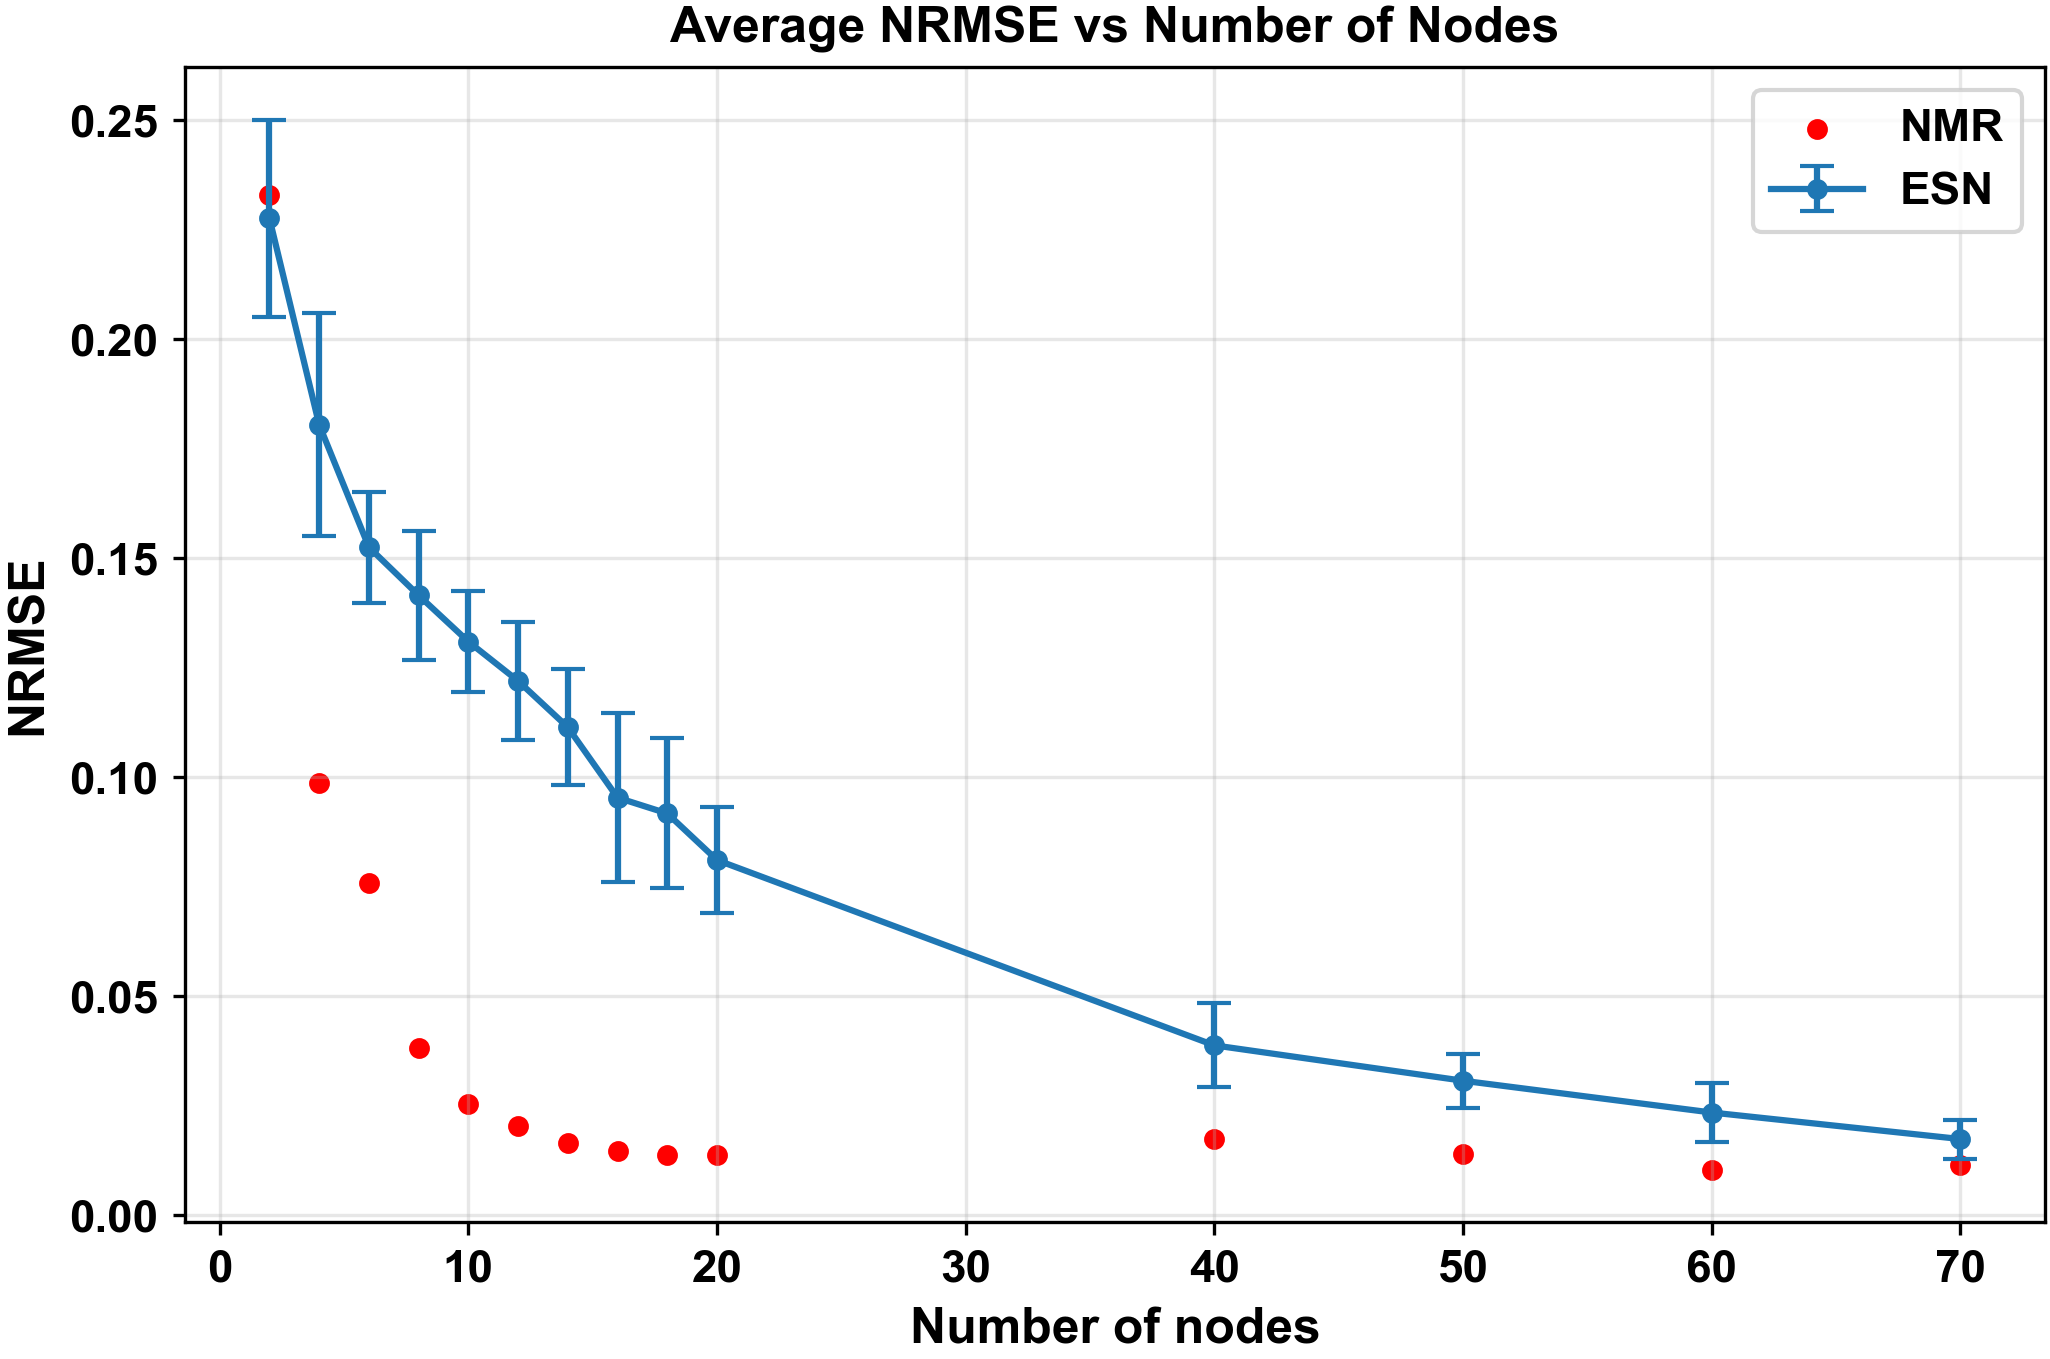

In [33]:
import numpy as np
import matplotlib.pyplot as plt

nodes = np.array(nodes)
plt.figure(figsize=(8, 5))
plt.errorbar(
    nodes,
    mean_errors,
    yerr=std_errors,
    marker='o',
    capsize=4,
    label='ESN'
)
plt.scatter(nodes,Quantum_errors,label='NMR',color='Red')

plt.xlabel("Number of nodes")
plt.ylabel("NRMSE")
plt.title("Average NRMSE vs Number of Nodes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('mackeyglass.png')
plt.show()

Observe how performance changes by omega

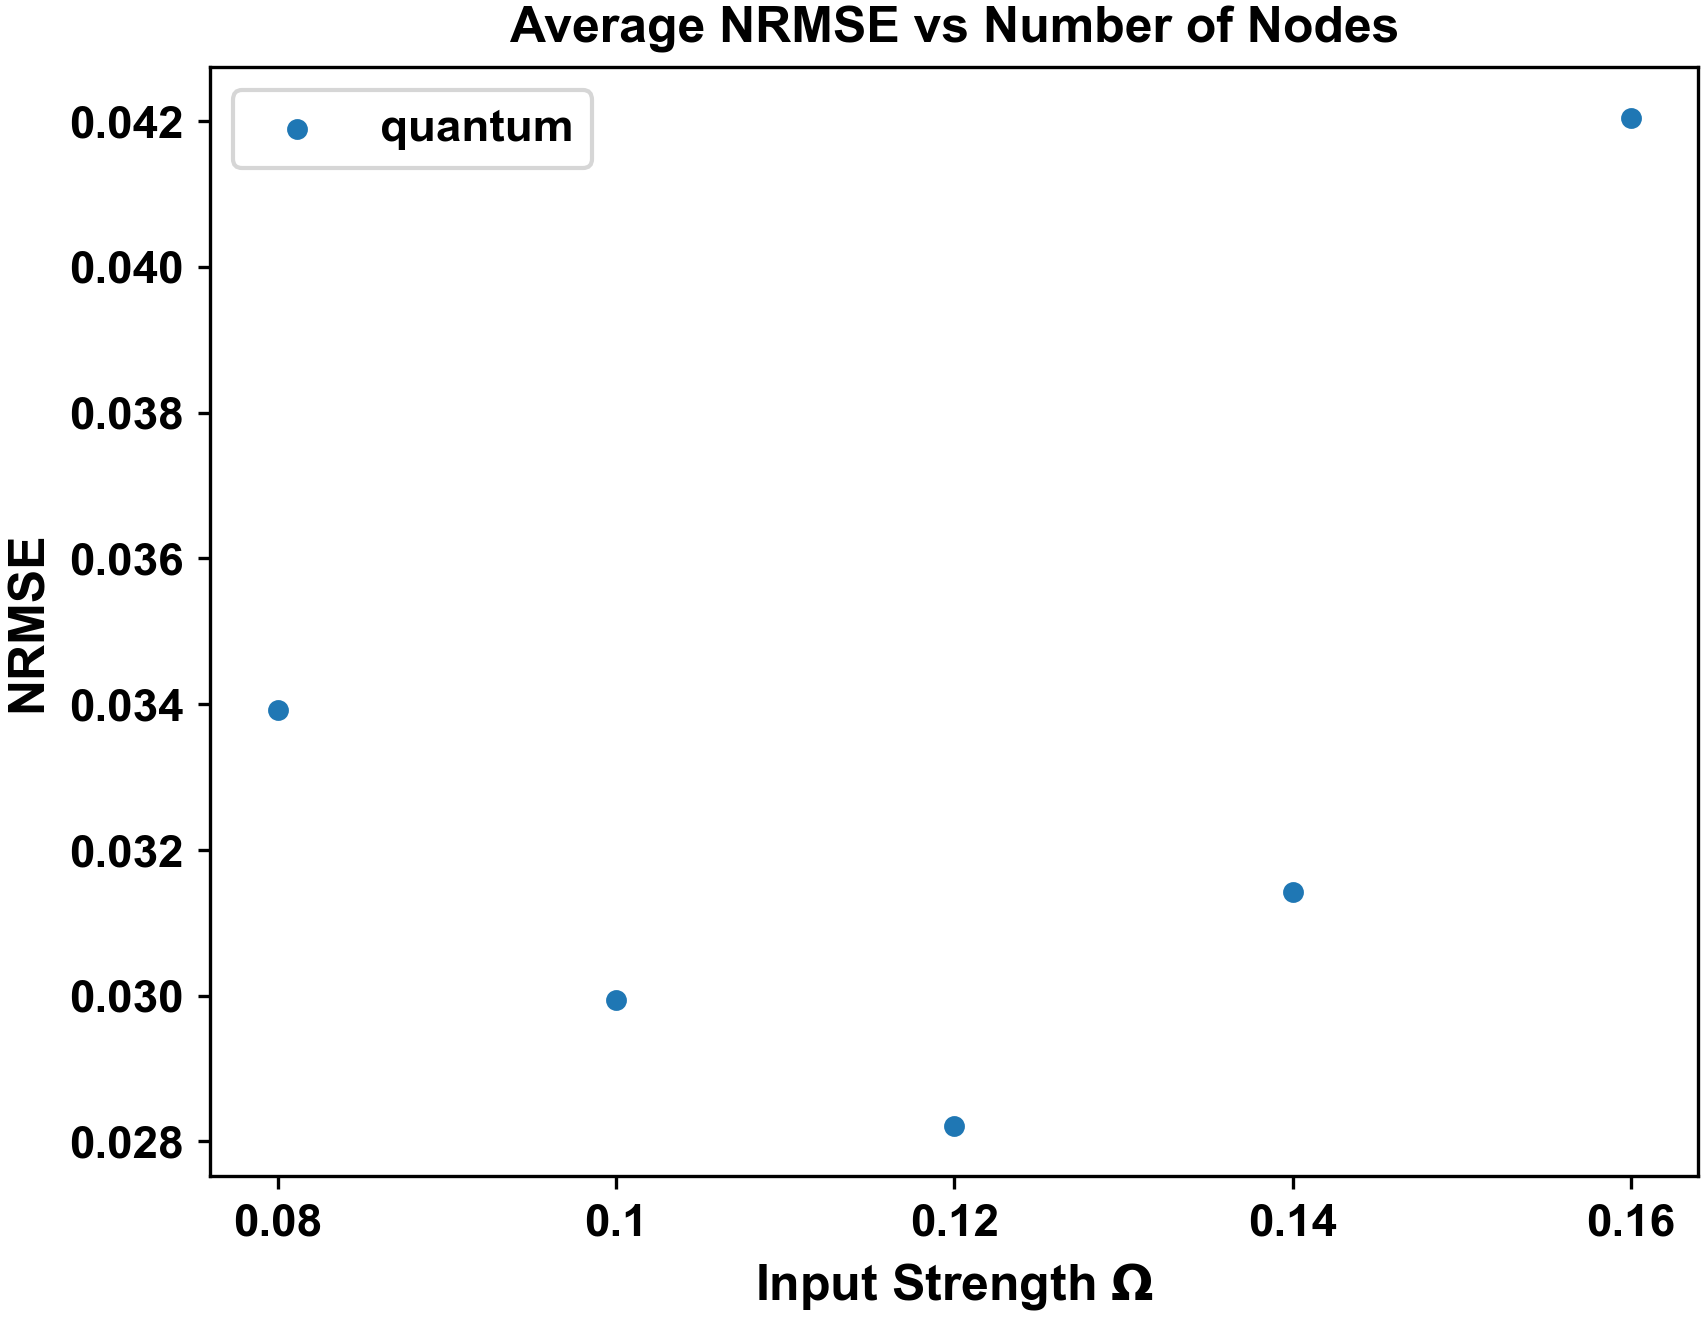

In [17]:
Quantum_errors = []
Nfading = 50
Ntraining = 750
Ntotal = 1000
Ntesting = Ntotal - Nfading - Ntraining
tau = 10
K = Ntotal-tau
rep = 10
omegas = ['0.08', '0.1', '0.12', '0.14', '0.16']
for omega in omegas: 
    name = f'MG_omega{omega}_rep{rep}.csv'
    df = pd.read_csv(name)
    X_quantum = extract_delayed_single_column(df, 'PQ-10', N=20, repeat_steps=rep)
    
    X_features_quantum = X_quantum[0:K]
    
    X_train_quantum = X_features_quantum[Nfading : Nfading + Ntraining, :]
    X_test_quantum = X_features_quantum[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]
    
    y_target = task[tau : K + tau]
    y_train = y_target[Nfading : Nfading + Ntraining]
    y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]
    
    W_quantum = fitting_function(X_train_quantum, y_train)
    y_prediction_quantum = predict(X_test_quantum, W_quantum)
    error = nrmse(y_prediction_quantum, y_test)
    Quantum_errors.append(error)

plt.scatter(omegas, Quantum_errors, label = 'quantum')
plt.xlabel(r"Input Strength $\Omega$")
plt.ylabel("NRMSE")
plt.title("Average NRMSE vs Number of Nodes")
plt.legend()

In [18]:
import pandas as pd
import numpy as np

df = pd.read_csv("X_features08.csv")
X = df.values

FileNotFoundError: [Errno 2] No such file or directory: 'X_features08.csv'

In [ ]:
QuantumNM_errors = []
QuantumCavity_errors = []
Nfading = 10
Ntraining = 790
Ntotal = 1000
Ntesting = Ntotal - Nfading - Ntraining
tau = 10
K = Ntotal-tau
rep = 5
omegas = ['0.08', '0.1', '0.12', '0.14', '0.16']
for omega in omegas: 
    name = f'MG_omega{omega}_rep{rep}.csv'
    df = pd.read_csv(name)
    X_NM = extract_delayed_single_column(df, 'PQ-10', N=6, repeat_steps=rep)
    print(X_NM.shape)
    df = pd.read_csv(f"X_features{omega}_2atoms.csv")
    X_cavity = df.values
    
    X_features_NM = X_NM[0:K]
    X_cavity = X_cavity[0:K]
    
    X_train_NM = X_features_NM[Nfading : Nfading + Ntraining, :]
    X_test_NM = X_features_NM[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]

    X_train_cavity = X_cavity[Nfading : Nfading + Ntraining, :]
    X_test_cavity = X_cavity[Nfading + Ntraining : Nfading + Ntraining + Ntesting,:]
    
    y_target = task[tau : K + tau]
    y_train = y_target[Nfading : Nfading + Ntraining]
    y_test = y_target[Nfading + Ntraining : Nfading + Ntraining + Ntesting]
    
    W_NM = fitting_function(X_train_NM, y_train)
    y_prediction_NM = predict(X_test_NM, W_NM)
    error = nrmse(y_prediction_NM, y_test)
    QuantumNM_errors.append(error)

    W_cavity = fitting_function(X_train_cavity, y_train)
    y_prediction_cavity = predict(X_test_cavity, W_cavity)
    error = nrmse(y_prediction_cavity, y_test)
    QuantumCavity_errors.append(error)

plt.scatter(omegas, QuantumNM_errors, label = 'quantum NM')
plt.scatter(omegas, QuantumCavity_errors, label = 'quantum Cavity')
plt.xlabel("Omegas")
plt.ylabel("NRMSE")
plt.title("Average NRMSE vs Drive Strength")
plt.legend()